# Healthcare Data Analysis

## Introduction: This notebook analyzes revenue across hospitals using different insurance providers. It also contains the information of patients such age, gender, blood group, medical condition, date of admission and discharge, medication administered, and name of doctor. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
healthcare = pd.read_csv(r"C:\Users\HomePC\Desktop\TECH\MY PROJECTS\Healthcare project\Healthcare_cleaned.csv")

In [24]:
healthcare.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length_of_stay,Age_category,Billing_category
0,Bobby Jackson,30,Male,B-,Cancer,1/31/2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,2/2/2024,Paracetamol,Normal,2,Adult,Medium
1,Leslie Terry,62,Male,A+,Obesity,8/20/2019,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,8/26/2019,Ibuprofen,Inconclusive,6,Elder,High
2,Danny Smith,76,Female,A-,Obesity,9/22/2022,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,10/7/2022,Aspirin,Normal,15,Elder,Medium
3,Andrew Watts,28,Female,O+,Diabetes,11/18/2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,12/18/2020,Ibuprofen,Abnormal,30,Adult,High
4,Adrienne Bell,43,Female,AB+,Cancer,9/19/2022,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,10/9/2022,Penicillin,Abnormal,20,Mid_aged,Low


In [25]:
healthcare.tail()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length_of_stay,Age_category,Billing_category
55495,Elizabeth Jackson,42,Female,O+,Asthma,8/16/2020,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.71,417,Elective,9/15/2020,Penicillin,Abnormal,30,Mid_aged,Low
55496,Kyle Perez,61,Female,AB-,Obesity,1/23/2020,Taylor Sullivan,Tucker-Moyer,Cigna,31457.80,316,Elective,2/1/2020,Aspirin,Normal,9,Elder,High
55497,Heather Wang,38,Female,B+,Hypertension,7/13/2020,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.76,347,Urgent,8/10/2020,Ibuprofen,Abnormal,28,Adult,Medium
55498,Jennifer Jones,43,Male,O-,Arthritis,5/25/2019,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.09,321,Elective,5/31/2019,Ibuprofen,Abnormal,6,Mid_aged,High
55499,James Garcia,53,Female,O+,Arthritis,4/2/2024,Dennis Warren,Henry Sons and,Aetna,4010.13,448,Urgent,4/29/2024,Ibuprofen,Abnormal,27,Mid_aged,Low


In [26]:
healthcare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
 15  Length_of_stay      55500 non-null  int64  
 16  Age_

In [27]:
healthcare.describe()

,Age,Billing Amount,Room Number,Length_of_stay
count,55500.000000,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316071,301.134829,15.509009
std,19.602454,14211.454434,115.243069,8.659600
min,13.000000,-2008.490000,101.000000,1.000000
25%,35.000000,13241.222500,202.000000,8.000000
50%,52.000000,25538.065000,302.000000,15.000000
75%,68.000000,37820.510000,401.000000,23.000000
max,89.000000,52764.280000,500.000000,30.000000


## Data Cleaning

In [51]:
#Convert Billing Amount

healthcare["Billing Amount"] = healthcare["Billing Amount"].replace("[$,]", "", regex=True).astype(float)

In [52]:
#Convert dates to proper data type

healthcare["Date of Admission"] = pd.to_datetime(healthcare["Date of Admission"])
healthcare["Discharge Date"] = pd.to_datetime(healthcare["Discharge Date"])

In [53]:
#Create hospital stay duration

healthcare["Length_of_stay"] = (healthcare["Discharge Date"] - healthcare["Date of Admission"]).dt.days
print(healthcare.dtypes)

Name                          object
Age                            int64
Gender                        object
Blood Type                    object
Medical Condition             object
Date of Admission     datetime64[ns]
Doctor                        object
Hospital                      object
Insurance Provider            object
Billing Amount               float64
Room Number                    int64
Admission Type                object
Discharge Date        datetime64[ns]
Medication                    object
Test Results                  object
Length_of_stay                 int64
Age_category                  object
Billing_category              object
dtype: object


## Analysis & Visualization

Insight: Diabetes patients generated the highest treatment costs.

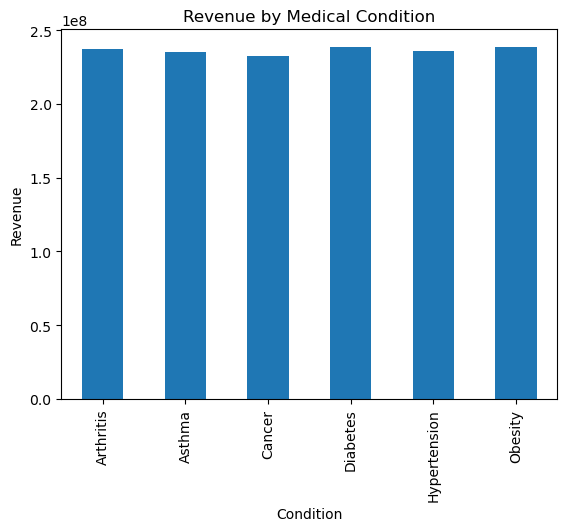

In [54]:
#Revenue generated by Medical Condition 

condition = healthcare.groupby("Medical Condition")["Billing Amount"].sum()
condition.plot(kind="bar")
plt.title("Revenue by Medical Condition")
plt.xlabel("Condition")
plt.ylabel("Revenue")
plt.show()

Insight: There was approximately an equal number of males and females admitted.
         However, males in the elderly age category had the highest average billing expenses. 

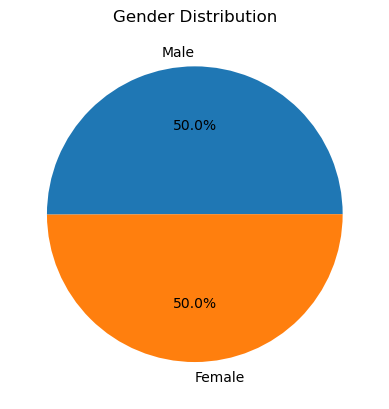

In [55]:
#Gender Distribution 

gender = healthcare["Gender"].value_counts()

gender.plot(kind="pie", autopct="%1.1f%%")

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

Insight: All the insurance providers had about the same average billing amount.

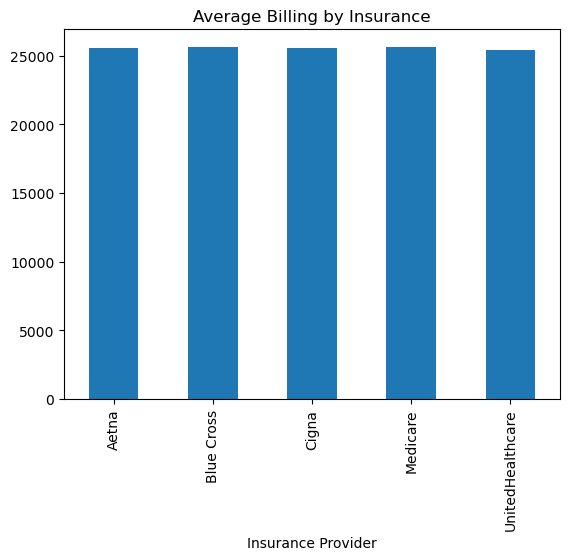

In [56]:
#Insurance Provider Analysis

insurance = healthcare.groupby("Insurance Provider")["Billing Amount"].mean()

insurance.plot(kind="bar")

plt.title("Average Billing by Insurance")
plt.show()

Insight: Emergency and elective admissions had longer average hospital stay than urgent admissions.
However, the difference is 1, which shows that admission type does not extremely affect the duration of a patient's hospital stay.

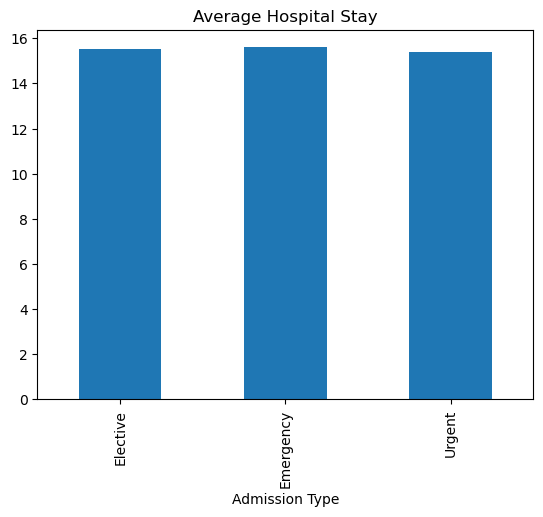

In [57]:
#Duration of Hospital Stay Analysis

stay = healthcare.groupby("Admission Type")["Length_of_stay"].mean()
stay.plot(kind="bar")
plt.title("Average Hospital Stay")
plt.show()

In [44]:
correlation = healthcare.corr(numeric_only=True)
print(correlation)

                     Age  Billing Amount  Room Number  Length_of_stay
Age             1.000000       -0.003832    -0.000720        0.008220
Billing Amount -0.003832        1.000000    -0.002943       -0.005602
Room Number    -0.000720       -0.002943     1.000000       -0.005526
Length_of_stay  0.008220       -0.005602    -0.005526        1.000000


## Recommendations

1. Allocate more staffs and beds to age categories with high admission rate, such as elderly males.
2. Redistribute doctors based on patients' age category load to prevent burnout.
3. Introduce preventive screening and early intervention programs for the elderly category, especially for diabetes.
4. Create gender specific health programs like maternal care, menstrual hygiene, focused on young adult and adult females. 
5. Offer discount to obessed patients who are unable to pay their bills. Discounts can also be given to teenagers whose parents cannot afford the treatment cost, considering that the admission count of the age category is low.  

## Conclusion

This project analyzed healthcare patient admission and billing data to identify trends in medical conditions, hospital admissions, insurance coverage, and treatment costs. Using Python for data cleaning, exploration, and visualization helped uncover key insights such as high-cost medical conditions, differences in billing across insurance providers, and patterns in hospital stay durations.
The analysis demonstrated how data analytics can support healthcare decision-making by improving operational efficiency, financial planning, and patient management. Overall, this project strengthened practical skills in data cleaning, exploratory data analysis, visualization, and business insight  using Python.